In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
SEED=34

In [67]:
df = pd.read_csv("../data/dataset.csv")

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [69]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [70]:
df.shape

(10000, 12)

# EDA

In [71]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


we will label encode college_tier and university_ranking_band since they have an order

In [72]:
df["college_tier"].value_counts()

college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64

In [73]:
college_tier_map = {"Tier 3":0, "Tier 2":1, "Tier 1":2}

In [74]:
df["college_tier"] = df["college_tier"].map(college_tier_map)

In [75]:
df["university_ranking_band"].value_counts()

university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64

In [76]:
ranking_map = {"300+":0,"100-300":1,"Top 100":2}

In [77]:
df["university_ranking_band"] = df["university_ranking_band"].map(ranking_map)

we will do the target encoding here to enable correlation analysis

In [78]:
target_map = {"Placed":1,"Not Placed":0}

In [79]:
df["placement_status"]=df["placement_status"].map(target_map)

In [80]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,1,Canada,1,2,53.574150,64.177062,Data Science,Consulting,5.481450,1
1,6.889389,0,0,UK,0,1,60.687750,88.346052,Data Science,Consulting,4.625099,1
2,7.518151,0,2,UK,1,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,1
3,8.218424,0,1,UK,1,3,73.461500,78.204854,AI/ML,Tech,5.150674,1
4,6.812677,1,1,USA,1,4,86.518121,44.680881,Data Science,Consulting,3.888824,1


In [81]:
categorical_col = df.select_dtypes(include=["object"]).columns
print(categorical_col)

Index(['country', 'specialization', 'industry'], dtype='object')


In [82]:
num_cols = df.select_dtypes(exclude=["object"]).columns
print(num_cols)

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score', 'placement_status'],
      dtype='object')


## Correlation Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

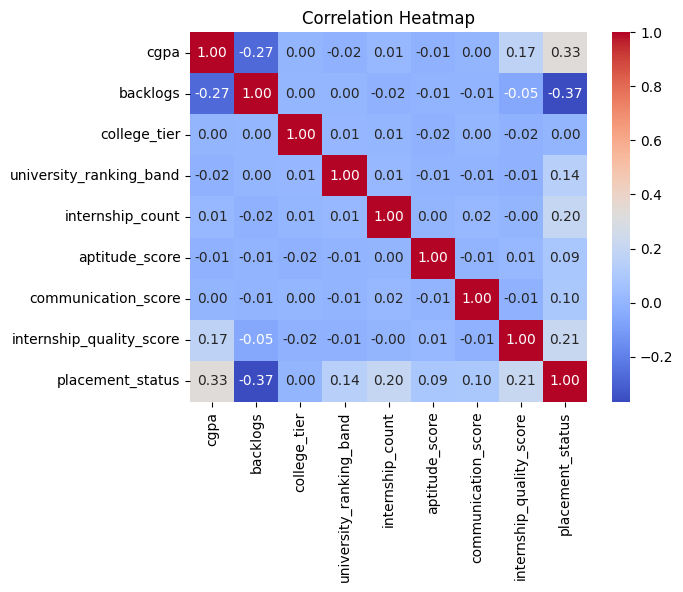

In [83]:
sns.heatmap(df[num_cols].corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")

## Distribution

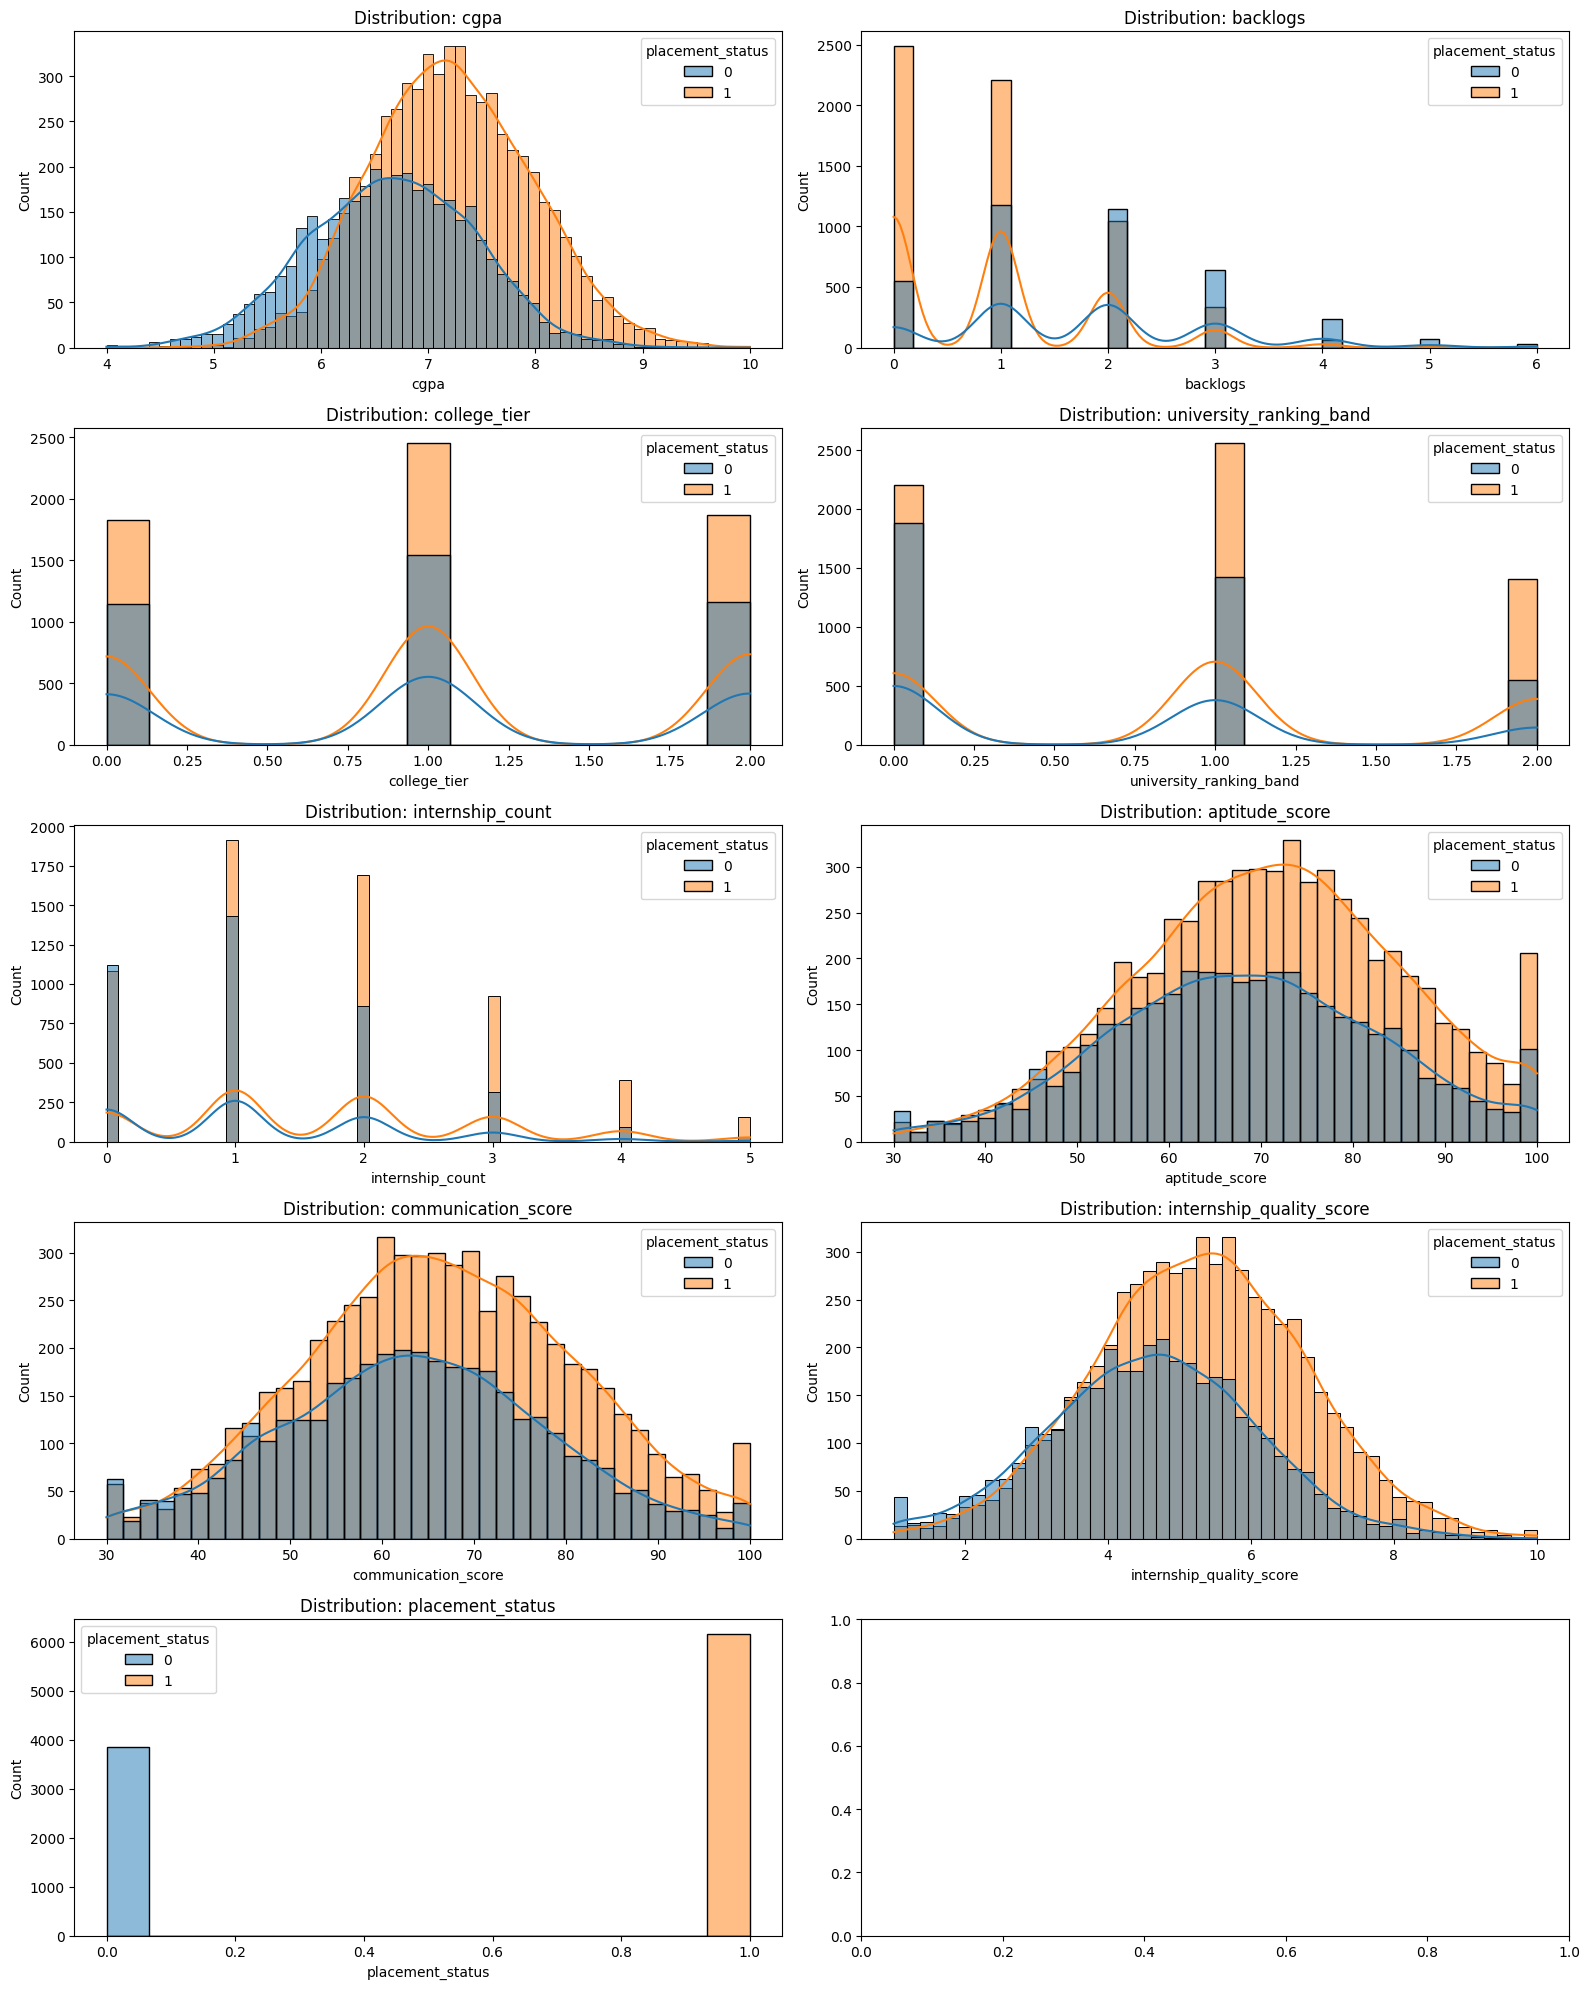

In [84]:
fig, ax = plt.subplots(5, 2, figsize=(16, 20))
for i, col in enumerate(num_cols):
    r, c = divmod(i, 2)
    sns.histplot(data=df,x=df[col], hue=df["placement_status"],ax=ax[r, c], kde=True)
    ax[r, c].set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Categorical Analysis

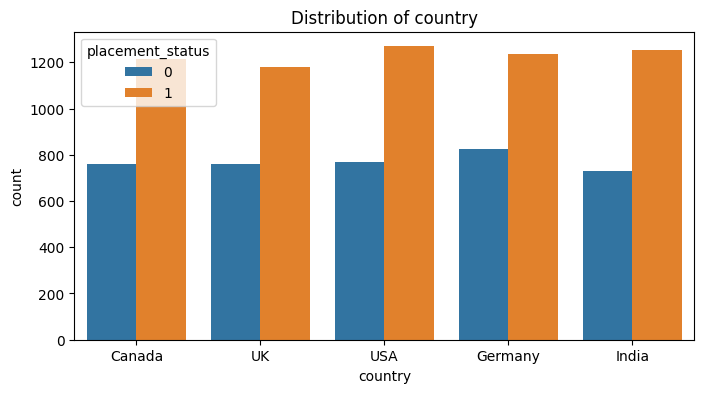

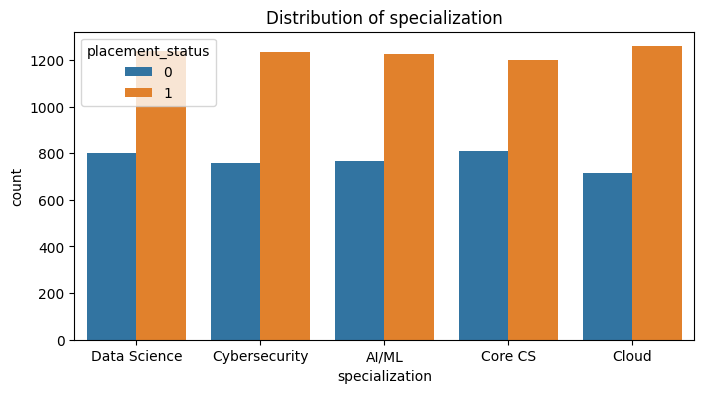

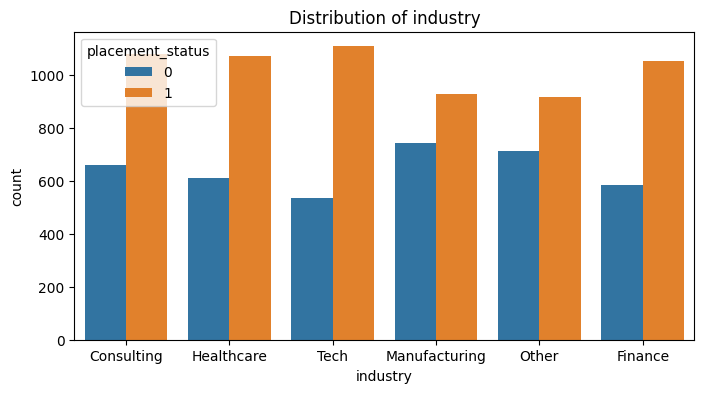

In [85]:
for col in categorical_col:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="placement_status")
    plt.title(f'Distribution of {col}')
    plt.show()

# Preprocess Pipeline

In [86]:
transformed_df = df.copy()

In [87]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.set_output(transform="pandas")

transformed_num_cols = transformed_df.select_dtypes(exclude="object").columns.drop("placement_status")
print(transformed_num_cols)

transformed_num_df = ss.fit_transform(transformed_df[transformed_num_cols])
transformed_num_df.head()

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score'],
      dtype='object')


,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116


In [88]:
oh_cols = ["country","specialization","industry"]

In [89]:
from sklearn.preprocessing import OneHotEncoder


onehot = OneHotEncoder(sparse_output=False)

one_hot_encoded = onehot.fit_transform(transformed_df[oh_cols])


one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot.get_feature_names_out(oh_cols))

transformed_encoded_df = pd.concat([transformed_num_df, one_hot_df], axis=1)

transformed_encoded_df.head()

,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score,country_Canada,country_Germany,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# Modelling

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [91]:
X = transformed_encoded_df
y = transformed_df["placement_status"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=SEED)

In [92]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 24), (2000, 24), (8000,), (2000,))

In [93]:
import ffnn

model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [94]:
model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001)
preds = model.predict(X_test)
print(f"Custom FFNN F1-Score : {f1_score(y_test, preds):.4f}")

Epoch 1/20 [==============================] - train_loss: 0.523942
Epoch 2/20 [==============================] - train_loss: 0.516804
Epoch 3/20 [==============================] - train_loss: 0.516844
Epoch 4/20 [==============================] - train_loss: 0.511603
Epoch 5/20 [==============================] - train_loss: 0.513496
Epoch 6/20 [==============================] - train_loss: 0.522582
Epoch 7/20 [==============================] - train_loss: 0.517531
Epoch 8/20 [==============================] - train_loss: 0.510182
Epoch 9/20 [==============================] - train_loss: 0.512382
Epoch 10/20 [==============================] - train_loss: 0.514237
Epoch 11/20 [==============================] - train_loss: 0.511995
Epoch 12/20 [==============================] - train_loss: 0.510765
Epoch 13/20 [==============================] - train_loss: 0.510896
Epoch 14/20 [==============================] - train_loss: 0.509275
Epoch 15/20 [==============================] - train_loss

In [95]:
from sklearn.neural_network import MLPClassifier

sk = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="relu",
    learning_rate="constant",
    learning_rate_init=1,
    max_iter=20,
    random_state=SEED,
)

In [96]:
sk.fit(X_train, y_train)
skpreds = sk.predict(X_test)
print(f"Sklearn MLP F1-Score : {f1_score(y_test, skpreds):.4f}")

Sklearn MLP F1-Score : 0.7620


c:\Users\varel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
